In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are saving your model as an HDF5 file"
)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib
import json

In [5]:
def load_saved_results():
    if not os.path.exists("results_store.json"):
        return None

    try:
        with open("results_store.json", "r") as f:
            data = json.load(f)
        print("✔ Previous results_store loaded.")
        return data
    except:
        print("✘ Error loading results_store.json")
        return None


def load_saved_models(split_id):
    models = {}

    # ML models
    ml_names = ["RandomForest", "SVM-RBF", "LogisticRegression", "KNN-5", "DecisionTree"]
    
    for name in ml_names:
        path = f"ml_model_split{split_id}_{name}.pkl"
        if os.path.exists(path):
            models[name] = joblib.load(path)
            print(f"✔ Loaded {name} model")

    # CNN
    cnn_path = f"cnn_split{split_id}.h5"
    if os.path.exists(cnn_path):
        models["CNN"] = load_model(cnn_path)
        print("✔ Loaded CNN model")

    # Hybrid
    hybrid_path = f"hybrid_split{split_id}.h5"
    if os.path.exists(hybrid_path):
        models["Hybrid"] = load_model(hybrid_path)
        print("✔ Loaded Hybrid model")

    return models


# ---------------- RUN THIS BLOCK AT NOTEBOOK START ----------------
results_store = load_saved_results()

if results_store:
    print("\n🎉 All saved results found. Training is NOT required.")
else:
    print("\n⚠ No saved results found. Please run the training cell next.")



⚠ No saved results found. Please run the training cell next.


In [6]:
df = pd.read_csv("exercise_angles.csv")
print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [7]:
# ============================================================
# 📌 CREATE 4 STRATIFIED SPLITS OF THE DATASET (LODO SETUP)
# ============================================================

from sklearn.model_selection import StratifiedKFold

# Separate features + labels
X_full = df.select_dtypes(include=['float64','int64']).iloc[:, :-1].values
y_full = df["Label"].values

# Create 4 stratified folds
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

splits = []  # This will store the 4 dataset partitions

for train_idx, test_idx in skf.split(X_full, y_full):
    X_train_split = X_full[train_idx]
    y_train_split = y_full[train_idx]
    X_test_split = X_full[test_idx]
    y_test_split = y_full[test_idx]
    splits.append((X_train_split, y_train_split, X_test_split, y_test_split))

print("\nDataset successfully split into 4 stratified parts!")



Dataset successfully split into 4 stratified parts!


In [8]:
# ============================================================
# 📌 PRINT DETAILS OF ALL 4 SPLITS
# ============================================================
for i, (X_train_split, y_train_split, X_test_split, y_test_split) in enumerate(splits):
    print(f"\n========== SPLIT {i+1} ==========")
    print(f"Training samples: {len(X_train_split)}")
    print(f"Testing samples : {len(X_test_split)}")
    print(f"Training class distribution:")
    
    # Class count in train
    unique, counts = np.unique(y_train_split, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"   {label}: {count}")
    
    print(f"Testing class distribution:")
    
    # Class count in test
    unique, counts = np.unique(y_test_split, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"   {label}: {count}")



========== SPLIT 1 ==========
Training samples: 23274
Testing samples : 7759
Training class distribution:
   Jumping Jacks: 3906
   Pull ups: 4994
   Push Ups: 7323
   Russian twists: 3303
   Squats: 3748
Testing class distribution:
   Jumping Jacks: 1303
   Pull ups: 1665
   Push Ups: 2441
   Russian twists: 1101
   Squats: 1249

========== SPLIT 2 ==========
Training samples: 23275
Testing samples : 7758
Training class distribution:
   Jumping Jacks: 3907
   Pull ups: 4995
   Push Ups: 7323
   Russian twists: 3303
   Squats: 3747
Testing class distribution:
   Jumping Jacks: 1302
   Pull ups: 1664
   Push Ups: 2441
   Russian twists: 1101
   Squats: 1250

========== SPLIT 3 ==========
Training samples: 23275
Testing samples : 7758
Training class distribution:
   Jumping Jacks: 3907
   Pull ups: 4994
   Push Ups: 7323
   Russian twists: 3303
   Squats: 3748
Testing class distribution:
   Jumping Jacks: 1302
   Pull ups: 1665
   Push Ups: 2441
   Russian twists: 1101
   Squats: 1249



In [9]:
print("🔹 First 5 Rows:\n", df.head(), "\n")
print("🔹 Shape:", df.shape, "\n") # Tell the number of rows and column
print("🔹 Columns:\n", df.columns, "\n") 
print("🔹 Dataset Info:\n")
print(df.info())
print()

🔹 First 5 Rows:
    Side  Shoulder_Angle  Elbow_Angle   Hip_Angle  Knee_Angle  Ankle_Angle  \
0  left       10.639208   174.466813  174.785143  179.848140   179.419276   
1  left       10.590342   174.428706  174.765042  179.775215   179.386147   
2  left       10.546746   174.489431  174.785790  179.660017   179.333710   
3  left       10.487682   174.614913  174.759542  179.614223   179.313926   
4  left       10.412107   174.758503  174.737721  179.570564   179.298805   

   Shoulder_Ground_Angle  Elbow_Ground_Angle  Hip_Ground_Angle  \
0                   90.0                90.0              90.0   
1                   90.0                90.0              90.0   
2                   90.0                90.0              90.0   
3                   90.0                90.0              90.0   
4                   90.0                90.0              90.0   

   Knee_Ground_Angle  Ankle_Ground_Angle          Label  
0               90.0                90.0  Jumping Jacks  
1      

In [10]:
print("🔹 Missing Values:\n", df.isnull().sum(), "\n")


🔹 Missing Values:
 Side                     0
Shoulder_Angle           0
Elbow_Angle              0
Hip_Angle                0
Knee_Angle               0
Ankle_Angle              0
Shoulder_Ground_Angle    0
Elbow_Ground_Angle       0
Hip_Ground_Angle         0
Knee_Ground_Angle        0
Ankle_Ground_Angle       0
Label                    0
dtype: int64 



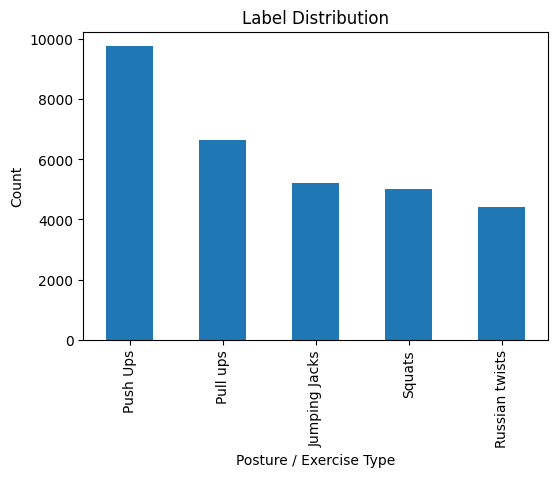

In [11]:
plt.figure(figsize=(6,4))
df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Posture / Exercise Type")
plt.ylabel("Count")
plt.show()

In [12]:
print("🔹 Statistical Summary of Numerical Columns:\n")
print(df.describe(), "\n")

🔹 Statistical Summary of Numerical Columns:

       Shoulder_Angle   Elbow_Angle     Hip_Angle    Knee_Angle   Ankle_Angle  \
count    31033.000000  31033.000000  31033.000000  31033.000000  31033.000000   
mean        66.522206    114.303010    137.466151    143.273623    135.211957   
std         60.226756     57.906279     57.048278     48.041715     53.304068   
min          0.002748      0.000974      0.006850      0.116036      0.031297   
25%         17.852184     58.900491    111.556724    123.646144    106.740814   
50%         40.585632    132.999090    168.374922    168.227063    162.926184   
75%        121.209005    168.769517    175.656498    177.225089    175.735039   
max        179.991577    179.998861    179.999848    179.999277    179.999942   

       Shoulder_Ground_Angle  Elbow_Ground_Angle  Hip_Ground_Angle  \
count           31033.000000        31033.000000      31033.000000   
mean               88.816743           88.926949         79.408694   
std            

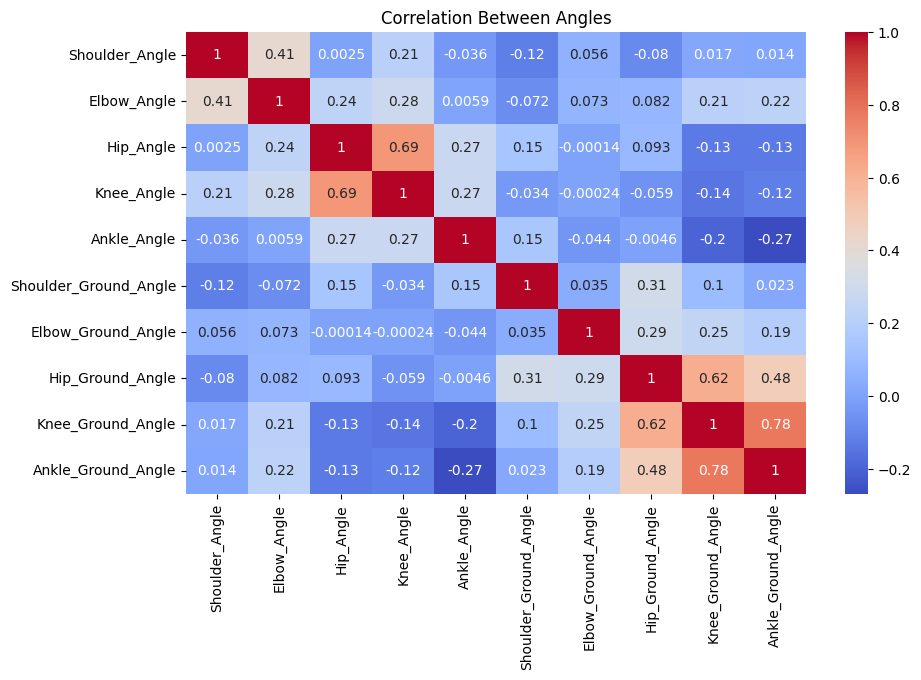

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Angles")
plt.show()

In [14]:
print("🔹 Unique Classes:", df["Label"].unique())

🔹 Unique Classes: ['Jumping Jacks' 'Squats' 'Push Ups' 'Pull ups' 'Russian twists']


In [15]:
import numpy as np 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split 
import joblib

In [16]:
# Detect numeric columns only
numeric_df = df.select_dtypes(include=['float64', 'int64']) # isolate numeric column

In [17]:
# Labels
y = df.iloc[:, -1].values # labbel
X = numeric_df.iloc[:, :-1].values # all numeric values

In [18]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
np.save("label_classes.npy", le.classes_) # save ki file

In [19]:
# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:

# SAVE scaler
joblib.dump(scaler, "angle_scaler.pkl")

['angle_scaler.pkl']

In [21]:
# Reshape for CNN
X = X.reshape(X.shape[0], X.shape[1], 1)
#CNN ko  3d input chahiye uske liye

In [22]:

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Final X shape:", X.shape)
print("Classes:", le.classes_)

Final X shape: (31033, 9, 1)
Classes: ['Jumping Jacks' 'Pull ups' 'Push Ups' 'Russian twists' 'Squats']


In [23]:
# ============================================================
# 📌 Utility Functions for Confusion Matrix, Accuracy, Loss
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import numpy as np

def plot_confusion_matrix_custom(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

def plot_training_curves(history, model_name, split_id):
    # Accuracy Plot
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{model_name} Accuracy Curve (Split {split_id})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss Plot
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{model_name} Loss Curve (Split {split_id})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


⚠ No saved results found. Training will start now...

===== TRAINING SPLIT 1 =====

📊 RandomForest | Split 1
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


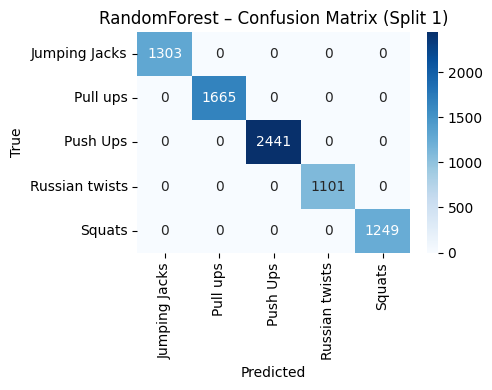


📊 SVM-RBF | Split 1
Accuracy  : 0.8862
Precision : 0.8880
Recall    : 0.8862
F1-score  : 0.8855


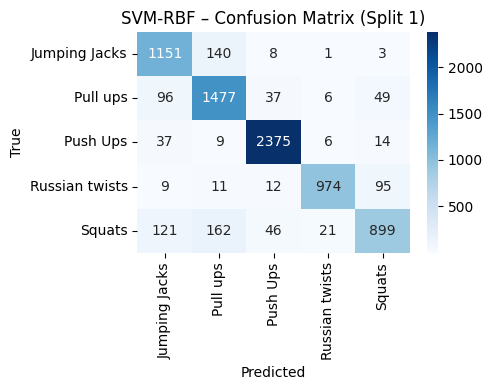


📊 LogisticRegression | Split 1
Accuracy  : 0.6951
Precision : 0.6987
Recall    : 0.6951
F1-score  : 0.6962


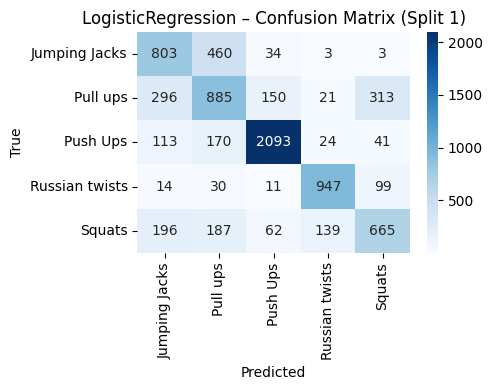


📊 KNN-5 | Split 1
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


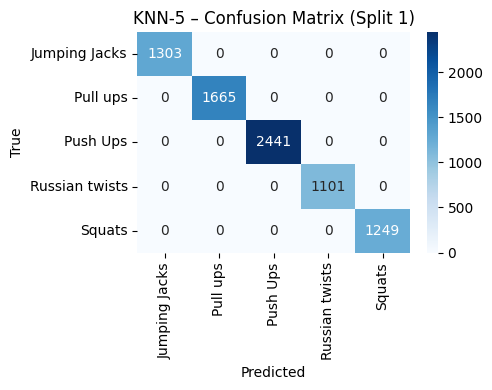


📊 DecisionTree | Split 1
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


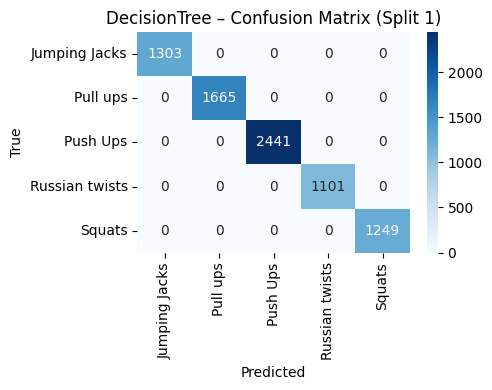

243/243 [==============================] - 1s 2ms/step
CNN Accuracy: 0.9553

📊 CNN | Split 1
Accuracy  : 0.9553
Precision : 0.9552
Recall    : 0.9553
F1-score  : 0.9550


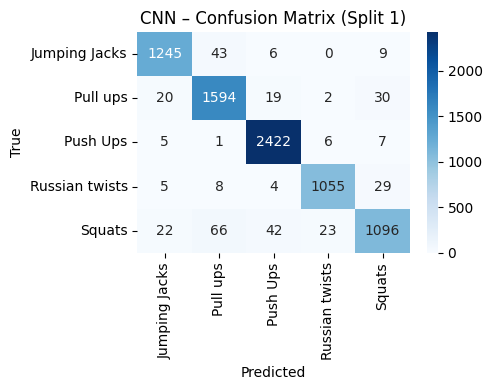

243/243 [==============================] - 2s 4ms/step
Hybrid Accuracy: 0.9780

📊 Hybrid Conv1D–BiLSTM | Split 1
Accuracy  : 0.9780
Precision : 0.9782
Recall    : 0.9780
F1-score  : 0.9780


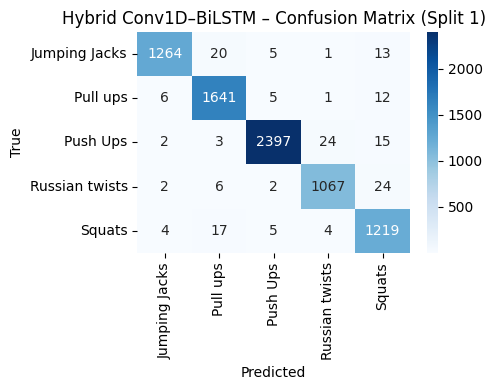


===== TRAINING SPLIT 2 =====

📊 RandomForest | Split 2
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


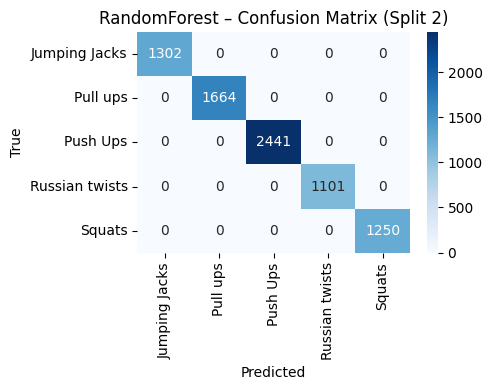


📊 SVM-RBF | Split 2
Accuracy  : 0.8938
Precision : 0.8954
Recall    : 0.8938
F1-score  : 0.8930


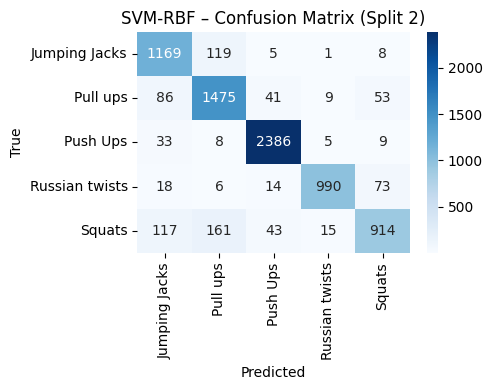


📊 LogisticRegression | Split 2
Accuracy  : 0.7040
Precision : 0.7076
Recall    : 0.7040
F1-score  : 0.7050


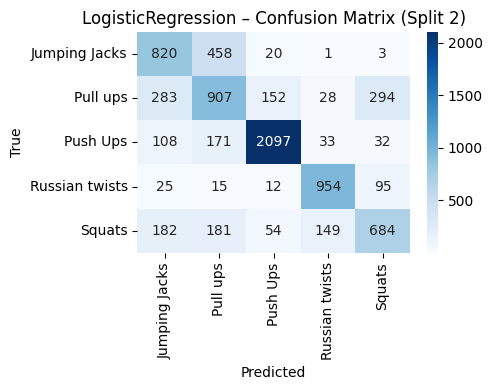


📊 KNN-5 | Split 2
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


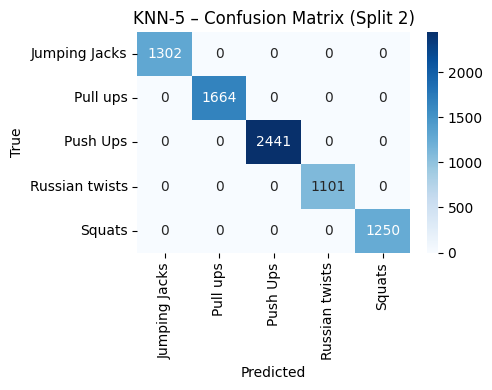


📊 DecisionTree | Split 2
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


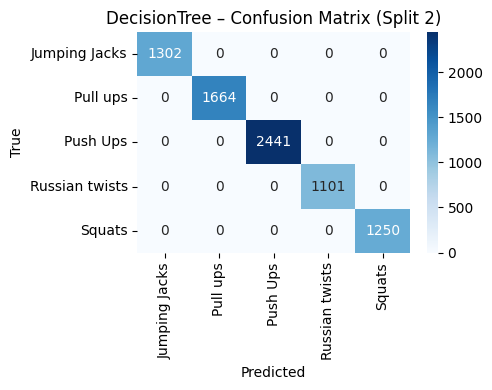

243/243 [==============================] - 1s 4ms/step
CNN Accuracy: 0.9629

📊 CNN | Split 2
Accuracy  : 0.9629
Precision : 0.9632
Recall    : 0.9629
F1-score  : 0.9628


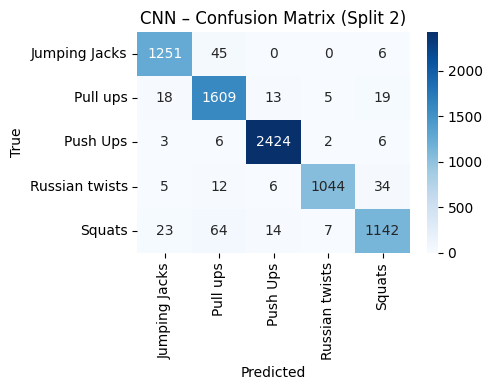

243/243 [==============================] - 4s 6ms/step
Hybrid Accuracy: 0.9832

📊 Hybrid Conv1D–BiLSTM | Split 2
Accuracy  : 0.9832
Precision : 0.9833
Recall    : 0.9832
F1-score  : 0.9832


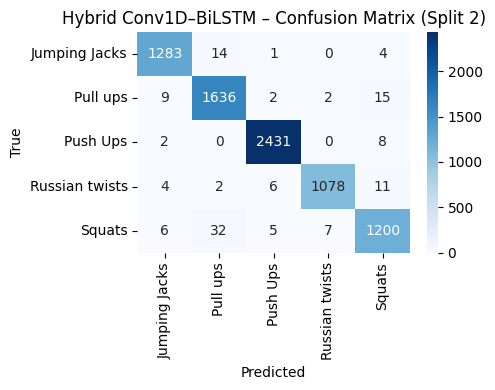


===== TRAINING SPLIT 3 =====

📊 RandomForest | Split 3
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


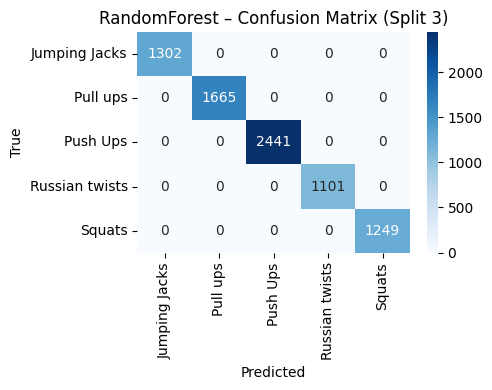


📊 SVM-RBF | Split 3
Accuracy  : 0.8962
Precision : 0.8978
Recall    : 0.8962
F1-score  : 0.8955


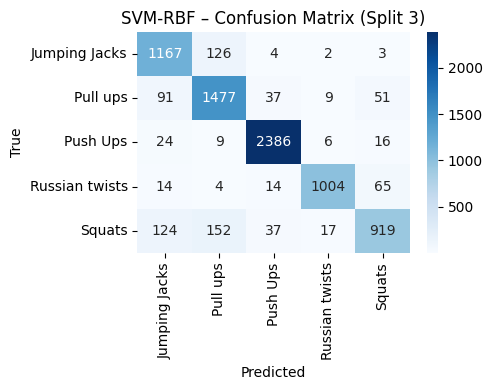


📊 LogisticRegression | Split 3
Accuracy  : 0.6973
Precision : 0.7021
Recall    : 0.6973
F1-score  : 0.6992


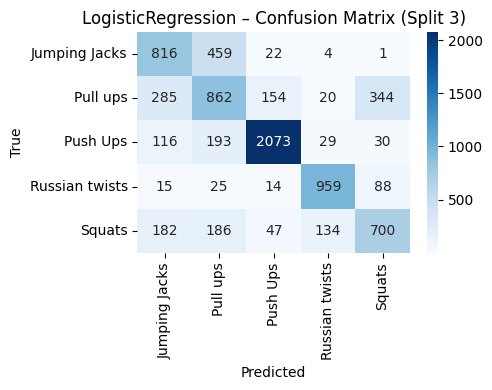


📊 KNN-5 | Split 3
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


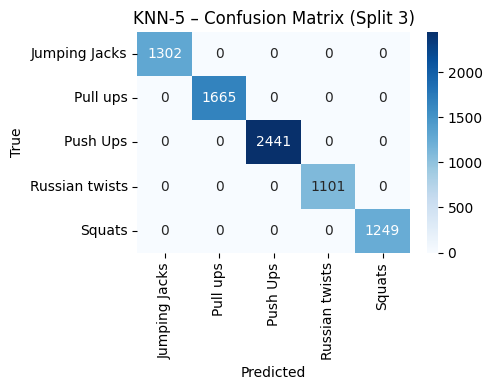


📊 DecisionTree | Split 3
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


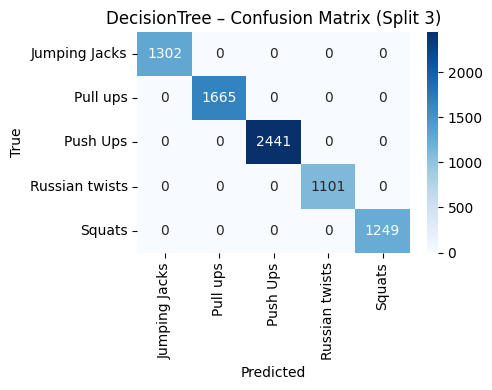

243/243 [==============================] - 0s 1ms/step
CNN Accuracy: 0.9464

📊 CNN | Split 3
Accuracy  : 0.9464
Precision : 0.9462
Recall    : 0.9464
F1-score  : 0.9462


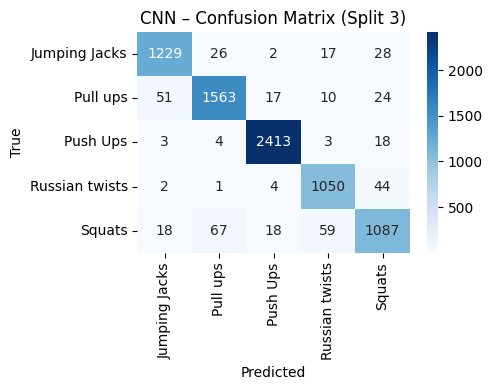

243/243 [==============================] - 1s 3ms/step
Hybrid Accuracy: 0.9777

📊 Hybrid Conv1D–BiLSTM | Split 3
Accuracy  : 0.9777
Precision : 0.9777
Recall    : 0.9777
F1-score  : 0.9777


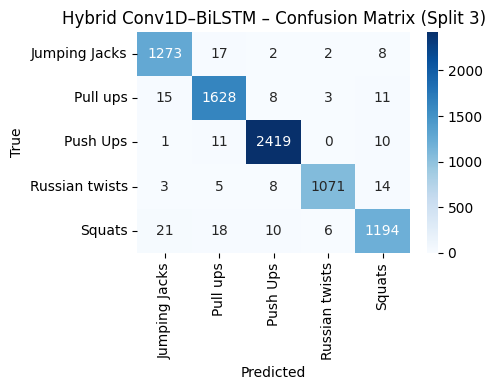


===== TRAINING SPLIT 4 =====

📊 RandomForest | Split 4
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


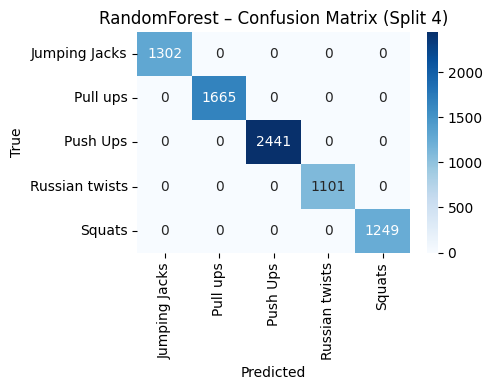


📊 SVM-RBF | Split 4
Accuracy  : 0.8929
Precision : 0.8940
Recall    : 0.8929
F1-score  : 0.8922


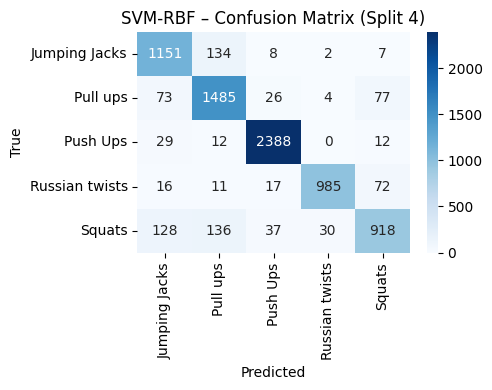


📊 LogisticRegression | Split 4
Accuracy  : 0.6963
Precision : 0.6983
Recall    : 0.6963
F1-score  : 0.6965


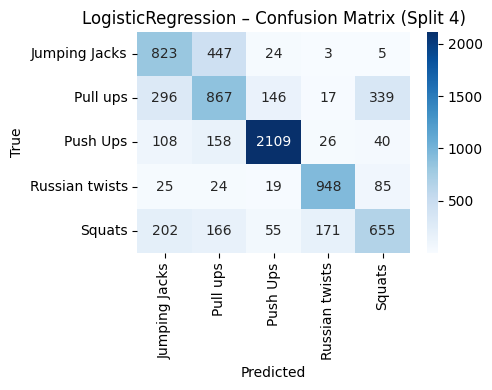


📊 KNN-5 | Split 4
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


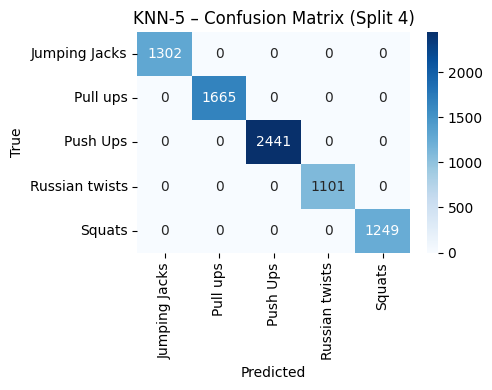


📊 DecisionTree | Split 4
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000


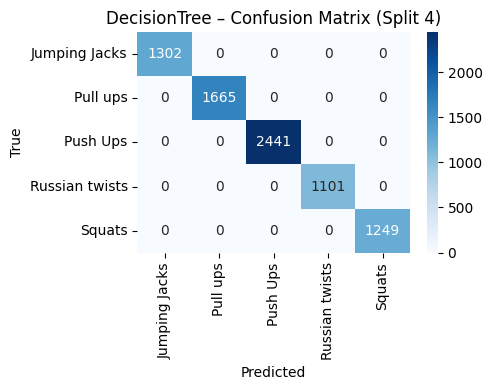

243/243 [==============================] - 0s 1ms/step
CNN Accuracy: 0.9617

📊 CNN | Split 4
Accuracy  : 0.9617
Precision : 0.9619
Recall    : 0.9617
F1-score  : 0.9617


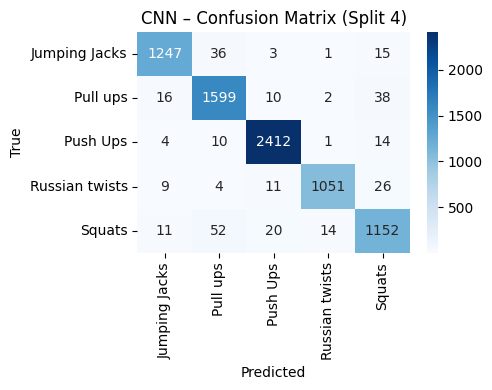

243/243 [==============================] - 1s 3ms/step
Hybrid Accuracy: 0.9765

📊 Hybrid Conv1D–BiLSTM | Split 4
Accuracy  : 0.9765
Precision : 0.9765
Recall    : 0.9765
F1-score  : 0.9765


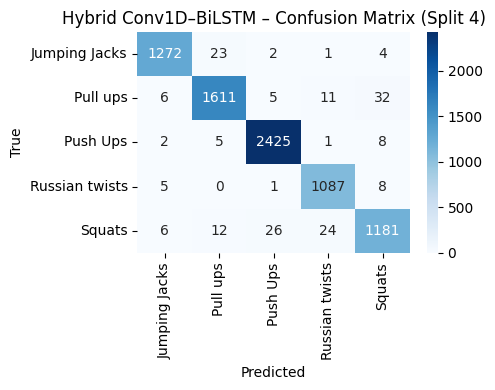


🎉 All models + results saved. Training complete!


In [24]:
import json
import joblib
import numpy as np
from sklearn.metrics import accuracy_score
from tensorflow.keras import models, layers
import os
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
def print_metrics(y_true, y_pred, model_name, split_id, labels=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 {model_name} | Split {split_id}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"{model_name} – Confusion Matrix (Split {split_id})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# ✅ THIS FUNCTION MUST BE OUTSIDE
def print_all_metrics_from_saved_results(results_store, le):
    for split_id in sorted(results_store.keys()):
        print(f"\n================ SPLIT {split_id} ================\n")

        # -------- ML MODELS (nested) --------
        for model_name, data in results_store[split_id]["ML"].items():
            y_true = np.array(data["y_true"])
            y_pred = np.array(data["y_pred"])

            print_metrics(
                y_true=y_true,
                y_pred=y_pred,
                model_name=f"ML - {model_name}",
                split_id=split_id,
                labels=le.classes_
            )

        # -------- CNN MODEL (single) --------
        cnn_data = results_store[split_id]["CNN"]
        if "y_true" in cnn_data:
            print_metrics(
                y_true=np.array(cnn_data["y_true"]),
                y_pred=np.array(cnn_data["y_pred"]),
                model_name="CNN",
                split_id=split_id,
                labels=le.classes_
            )

        # -------- HYBRID MODEL (single) --------
        hybrid_data = results_store[split_id]["Hybrid"]
        if "y_true" in hybrid_data:
            print_metrics(
                y_true=np.array(hybrid_data["y_true"]),
                y_pred=np.array(hybrid_data["y_pred"]),
                model_name="Hybrid Conv1D–BiLSTM",
                split_id=split_id,
                labels=le.classes_
            )



# =====================================================
# 1) CHECK IF PRETRAINED RESULTS EXIST
# =====================================================
if os.path.exists("results_store.json"):
    print("✔ Saved results found. Skipping training...")

    with open("results_store.json", "r") as f:
        results_store = json.load(f)

    results_store = {int(k): v for k, v in results_store.items()}

    # 🔥 PRINT ALL METRICS FROM SAVED RESULTS
    print_all_metrics_from_saved_results(results_store, le)

else:
    print("⚠ No saved results found. Training will start now...")
    results_store = {} 
    # Create clean folder structure
    os.makedirs("models/ml", exist_ok=True)
    os.makedirs("models/cnn", exist_ok=True)
    os.makedirs("models/hybrid", exist_ok=True)
    os.makedirs("results", exist_ok=True)

    for split_id in range(4):
        print(f"\n===== TRAINING SPLIT {split_id+1} =====")

        # ------------------ Prepare Data ---------------------
        X_test = splits[split_id][2]
        y_test = le.transform(splits[split_id][3])

        X_train = np.vstack([splits[j][0] for j in range(4) if j != split_id])
        y_train = np.hstack([splits[j][1] for j in range(4) if j != split_id])
        y_train = le.transform(y_train)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # Store results for this split
        results_store[split_id+1] = {
            "ML": {},
            "CNN": {},
            "Hybrid": {}
        }

        # ------------------ ML MODELS ------------------------
        ml_models = {
            "RandomForest": RandomForestClassifier(),
            "SVM-RBF": SVC(kernel='rbf'),
            "LogisticRegression": LogisticRegression(max_iter=2000),
            "KNN-5": KNeighborsClassifier(n_neighbors=5),
            "DecisionTree": DecisionTreeClassifier()
        }

        for name, clf in ml_models.items():
            clf.fit(X_train_scaled, y_train)
            preds = clf.predict(X_test_scaled)
            
            print_metrics(
                y_true=y_test,
                y_pred=preds,
                model_name=name,
                split_id=split_id + 1,
                labels=le.classes_
            )
            acc = accuracy_score(y_test, preds)
            # store results
            results_store[split_id+1]["ML"][name] = {
                "acc": acc,
                "y_true": y_test.tolist(),
                "y_pred": preds.tolist()
            }

            # ---------------- SAVE BLOCK ----------------
            joblib.dump(clf, f"models/ml/split{split_id+1}_{name}.pkl")

        # ------------------ CNN MODEL ------------------------
        X_train_cnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
        X_test_cnn  = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

        cnn = models.Sequential([
            layers.Input(shape=(X_train_cnn.shape[1], 1)),
            layers.Conv1D(64, 3, activation='relu'),
            layers.MaxPooling1D(2),
            layers.Conv1D(128, 3, activation='relu'),
            layers.GlobalMaxPooling1D(),
            layers.Dense(64, activation='relu'),
            layers.Dense(len(le.classes_), activation='softmax')
        ])

        cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        history_cnn = cnn.fit(
            X_train_cnn, y_train,
            validation_data=(X_test_cnn, y_test),
            epochs=15,
            batch_size=32,
            verbose=0
        )

        y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
        acc_cnn = accuracy_score(y_test, y_pred_cnn)

        results_store[split_id+1]["CNN"] = {
            "acc": acc_cnn,
            "history": history_cnn.history,
            "y_true": y_test.tolist(),
            "y_pred": y_pred_cnn.tolist()
        }

        print(f"CNN Accuracy: {acc_cnn:.4f}")
        print_metrics(
            y_true=y_test,
            y_pred=y_pred_cnn,
            model_name="CNN",
            split_id=split_id+1,
            labels=le.classes_
        )

        

        # ---------------- SAVE BLOCK ----------------
        cnn.save(f"models/cnn/split{split_id+1}.h5")

        # ------------------ Hybrid MODEL -------------------
        hybrid = models.Sequential([
            layers.Input(shape=(X_train_cnn.shape[1], 1)),
            layers.Conv1D(64, 3, activation='relu'),
            layers.Conv1D(128, 3, activation='relu'),
            layers.MaxPooling1D(2),
            layers.Bidirectional(layers.LSTM(64)),
            layers.Dense(128, activation='relu'),
            layers.Dense(len(le.classes_), activation='softmax')
        ])

        hybrid.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        history_hybrid = hybrid.fit(
            X_train_cnn, y_train,
            validation_data=(X_test_cnn, y_test),
            epochs=15,
            batch_size=32,
            verbose=0
        )

        y_pred_hybrid = np.argmax(hybrid.predict(X_test_cnn), axis=1)
        acc_hybrid = accuracy_score(y_test, y_pred_hybrid)

        results_store[split_id+1]["Hybrid"] = {
            "acc": acc_hybrid,
            "history": history_hybrid.history,
            "y_true": y_test.tolist(),
            "y_pred": y_pred_hybrid.tolist()
        }

        print(f"Hybrid Accuracy: {acc_hybrid:.4f}")
        print_metrics(
            y_true=y_test,
            y_pred=y_pred_hybrid,
            model_name="Hybrid Conv1D–BiLSTM",
            split_id=split_id+1,
            labels=le.classes_
        )


        # ---------------- SAVE BLOCK ----------------
        hybrid.save(f"models/hybrid/split{split_id+1}.h5")

    with open("results_store.json", "w") as f:
        json.dump(results_store, f)

    print("\n🎉 All models + results saved. Training complete!")
    
      # ONLY create when training
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def final_aggregated_metrics(results_store, le, model_type, model_name=None):

    all_y_true = []
    all_y_pred = []

    for split_id in sorted(results_store.keys()):
        print(f"Collecting Split {split_id}")  # DEBUG LINE

        if model_type == "ML":
            data = results_store[split_id]["ML"][model_name]
        else:
            data = results_store[split_id][model_type]

        all_y_true.extend(data["y_true"])
        all_y_pred.extend(data["y_pred"])

    print("Total samples:", len(all_y_true))  # DEBUG LINE

    y_true = np.array(all_y_true)
    y_pred = np.array(all_y_pred)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score(y_true, y_pred, average="weighted")
    f1   = f1_score(y_true, y_pred, average="weighted")

    print("\n================ FINAL RESULT ================")
    print("Model     :", model_name if model_name else model_type)
    print("Accuracy  :", round(acc, 4))
    print("Precision :", round(prec, 4))
    print("Recall    :", round(rec, 4))
    print("F1-score  :", round(f1, 4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f"Final Confusion Matrix – {model_name if model_name else model_type}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
